In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("Computer vision ready! ✅")

TensorFlow version: 2.21.0
Computer vision ready! ✅


In [2]:
# Load famous MNIST dataset - 70,000 handwritten digit images!
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training images: {X_train.shape}")
print(f"Test images: {X_test.shape}")
print(f"Each image is: {X_train[0].shape} pixels")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step
Training images: (60000, 28, 28)
Test images: (10000, 28, 28)
Each image is: (28, 28) pixels


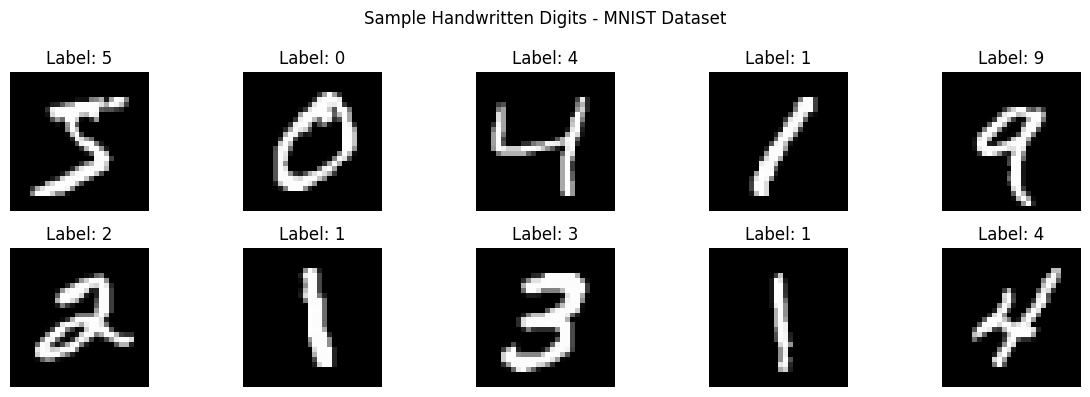

In [3]:
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle('Sample Handwritten Digits - MNIST Dataset')
plt.tight_layout()
plt.show()

In [4]:
# Normalize images
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build neural network
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Train
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=1)
print("Training complete! ✅")

C:\Users\PC\Desktop\Kenny\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9204 - loss: 0.2720 - val_accuracy: 0.9588 - val_loss: 0.1405
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9665 - loss: 0.1130 - val_accuracy: 0.9662 - val_loss: 0.1132
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9757 - loss: 0.0776 - val_accuracy: 0.9697 - val_loss: 0.1028
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9824 - loss: 0.0563 - val_accuracy: 0.9710 - val_loss: 0.1039
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9856 - loss: 0.0446 - val_accuracy: 0.9758 - val_loss: 0.0903
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9888 - loss: 0.0350 - val_accuracy: 0.9729 - val_loss: 0.1042
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9907 - loss: 0.0301 - val_accuracy: 0.9728 - val_loss: 0.1114
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9921 - loss: 0.0

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9760 - loss: 0.0984

Test Accuracy: 97.60%


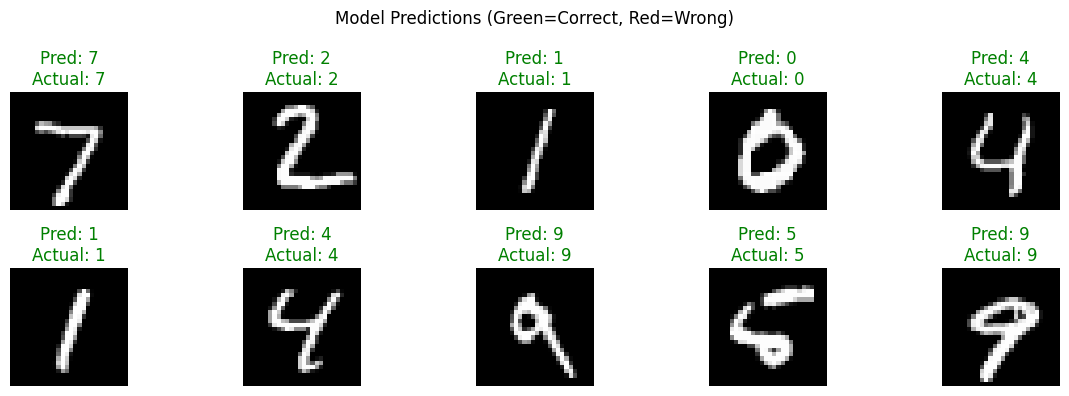

In [5]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")

# Show predictions
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i], cmap='gray')
    prediction = np.argmax(model.predict(X_test[i:i+1], verbose=0))
    actual = y_test[i]
    color = 'green' if prediction == actual else 'red'
    plt.title(f"Pred: {prediction}\nActual: {actual}", color=color)
    plt.axis('off')
plt.suptitle('Model Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()